# YouTube Shorts: Engagement & Growth Velocity Analysis

This notebook analyzes a curated dataset of viral YouTube Shorts to identify the drivers of algorithmic momentum and audience interaction. The project transitions through data preprocessing, exploratory data analysis (EDA), and Natural Language Processing (NLP) to decode what makes short-form content successful.
* Author-Shravan Padhar
* Date-19 March 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import emoji

In [2]:
import warnings
warnings.filterwarnings("ignore")

## DATA LOADING

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "YouTube_Shorts_Engagement_and_Growth_Velocity.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "kanchana1990/youtube-shorts-engagement-and-growth-velocity",
  file_path,
)
df.head()

,Video_ID,Title,Channel_Name,Views,Likes,Comments,Age_In_Days,Engagement_Rate_%,Views_Per_Day,Video_URL,Description_Length
0,XcTzxw9JAnM,How YouTube Wants You to Make Shorts,Think Media,23945,862,120,201,4.1011,119.13,https://www.youtube.com/watch?v=XcTzxw9JAnM,4546
1,fKIqusb14E0,Most Viewed YouTube Shorts! *VIRAL*,Stay Wild Reacts,16456884,129000,4863,342,0.8134,48119.54,https://www.youtube.com/watch?v=fKIqusb14E0,217
2,E_goHQxVmb4,How to Make Money with YouTube Shorts (Full Gu...,Alex Christian,326589,10000,938,270,3.3492,1209.59,https://www.youtube.com/watch?v=E_goHQxVmb4,1505
3,1EAus8qZeyM,How to Make a YouTube Short - Complete Beginne...,vidIQ,1778131,25000,2261,989,1.5331,1797.91,https://www.youtube.com/watch?v=1EAus8qZeyM,1001
4,oCxrIij2iXo,*NEW* World’s MOST Viewed YouTube Shorts!,MoreAliA,1307628,7500,443,85,0.6074,15383.86,https://www.youtube.com/watch?v=oCxrIij2iXo,1253


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 799 entries, 0 to 798
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Video_ID            799 non-null    object 
 1   Title               799 non-null    object 
 2   Channel_Name        799 non-null    object 
 3   Views               799 non-null    int64  
 4   Likes               799 non-null    int64  
 5   Comments            799 non-null    int64  
 6   Age_In_Days         799 non-null    int64  
 7   Engagement_Rate_%   799 non-null    float64
 8   Views_Per_Day       799 non-null    float64
 9   Video_URL           799 non-null    object 
 10  Description_Length  799 non-null    int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 68.8+ KB


In [5]:
df.describe()

,Views,Likes,Comments,Age_In_Days,Engagement_Rate_%,Views_Per_Day,Description_Length
count,7.990000e+02,7.990000e+02,799.000000,799.000000,799.000000,7.990000e+02,799.000000
mean,2.818712e+07,2.979908e+05,2295.652065,404.062578,1.860502,2.221636e+05,449.929912
std,1.095231e+08,1.164391e+06,12326.995689,819.671198,1.961120,5.605906e+05,844.828045
min,3.030000e+02,0.000000e+00,0.000000,1.000000,0.000000,3.200000e-01,0.000000
25%,5.443115e+05,5.100000e+03,55.000000,9.000000,0.605600,8.636085e+03,0.000000
50%,2.850459e+06,2.500000e+04,320.000000,147.000000,1.298000,4.811954e+04,67.000000
75%,1.499787e+07,1.570000e+05,1469.500000,395.500000,2.452100,2.069091e+05,557.000000
max,2.138155e+09,2.200000e+07,317800.000000,6728.000000,18.811900,7.045530e+06,4997.000000


In [6]:
df.isnull().sum()

Video_ID              0
Title                 0
Channel_Name          0
Views                 0
Likes                 0
Comments              0
Age_In_Days           0
Engagement_Rate_%     0
Views_Per_Day         0
Video_URL             0
Description_Length    0
dtype: int64

## EXPLORATORY DATA ANALYSIS (EDA)

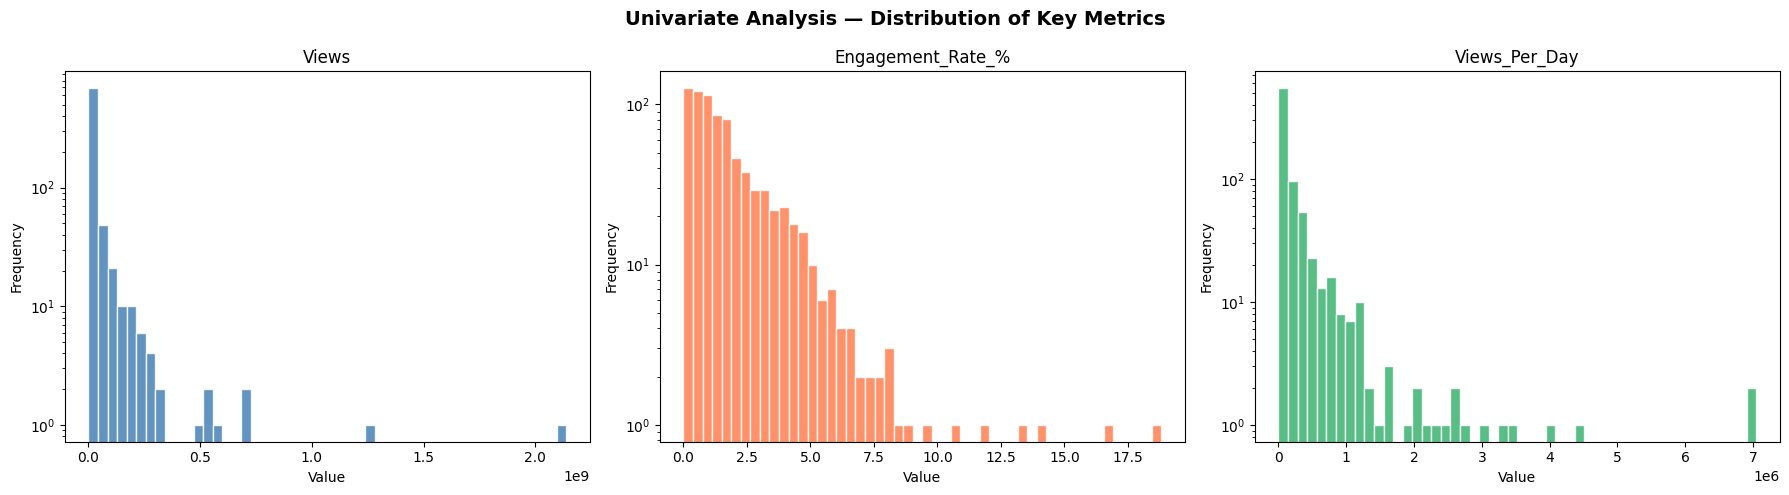

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Univariate Analysis — Distribution of Key Metrics", fontsize=14, fontweight="bold")
 
for ax, col, color in zip(
    axes,
    ["Views", "Engagement_Rate_%", "Views_Per_Day"],
    ["steelblue", "coral", "mediumseagreen"],
):
    ax.hist(df[col], bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.set_yscale("log")          # log-scale to show skewness clearly
 
plt.tight_layout()
plt.savefig("01_univariate_histograms.png", dpi=150)
plt.show()

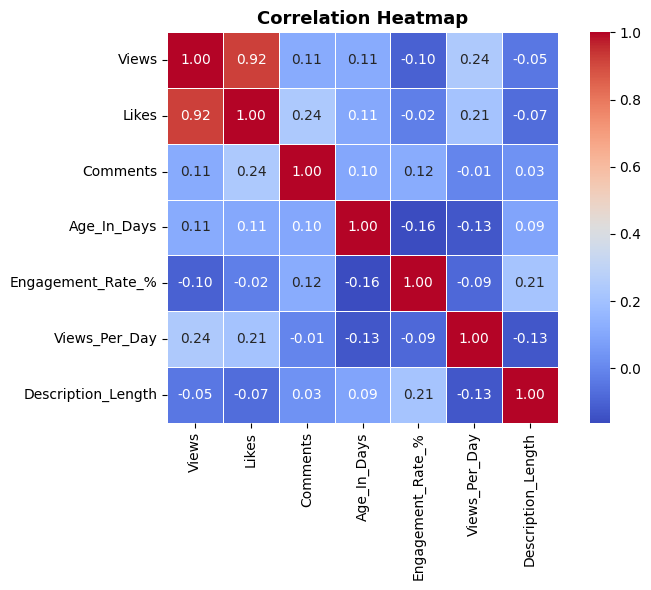

In [8]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr_cols = ["Views", "Likes", "Comments", "Age_In_Days",
             "Engagement_Rate_%", "Views_Per_Day", "Description_Length"]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True)
plt.title("Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("02_correlation_heatmap.png", dpi=150)
plt.show()

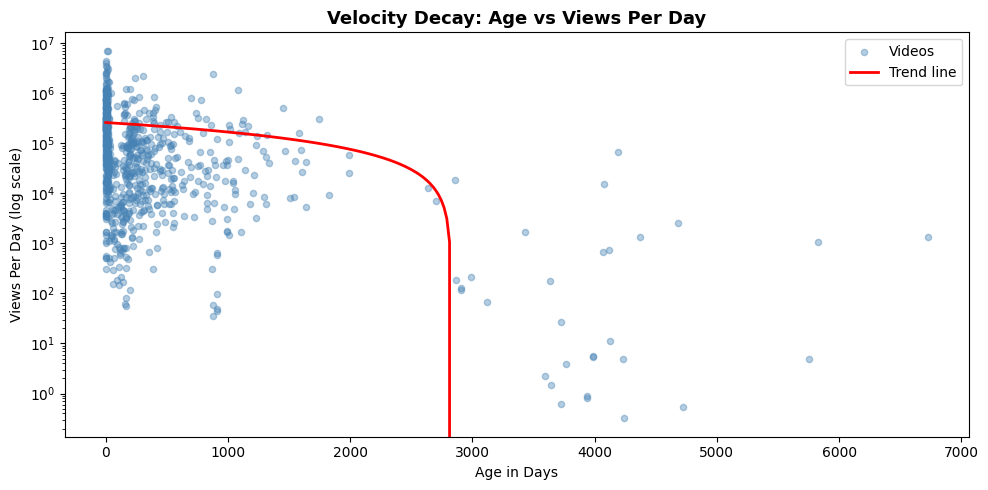

In [9]:
plt.figure(figsize=(10, 5))
plt.scatter(df["Age_In_Days"], df["Views_Per_Day"],
            alpha=0.4, color="steelblue", s=20, label="Videos")
z = np.polyfit(df["Age_In_Days"], df["Views_Per_Day"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["Age_In_Days"].min(), df["Age_In_Days"].max(), 300)
plt.plot(x_line, p(x_line), color="red", linewidth=2, label="Trend line")
plt.yscale("log")
plt.xlabel("Age in Days")
plt.ylabel("Views Per Day (log scale)")
plt.title("Velocity Decay: Age vs Views Per Day", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("03_velocity_decay.png", dpi=150)
plt.show()

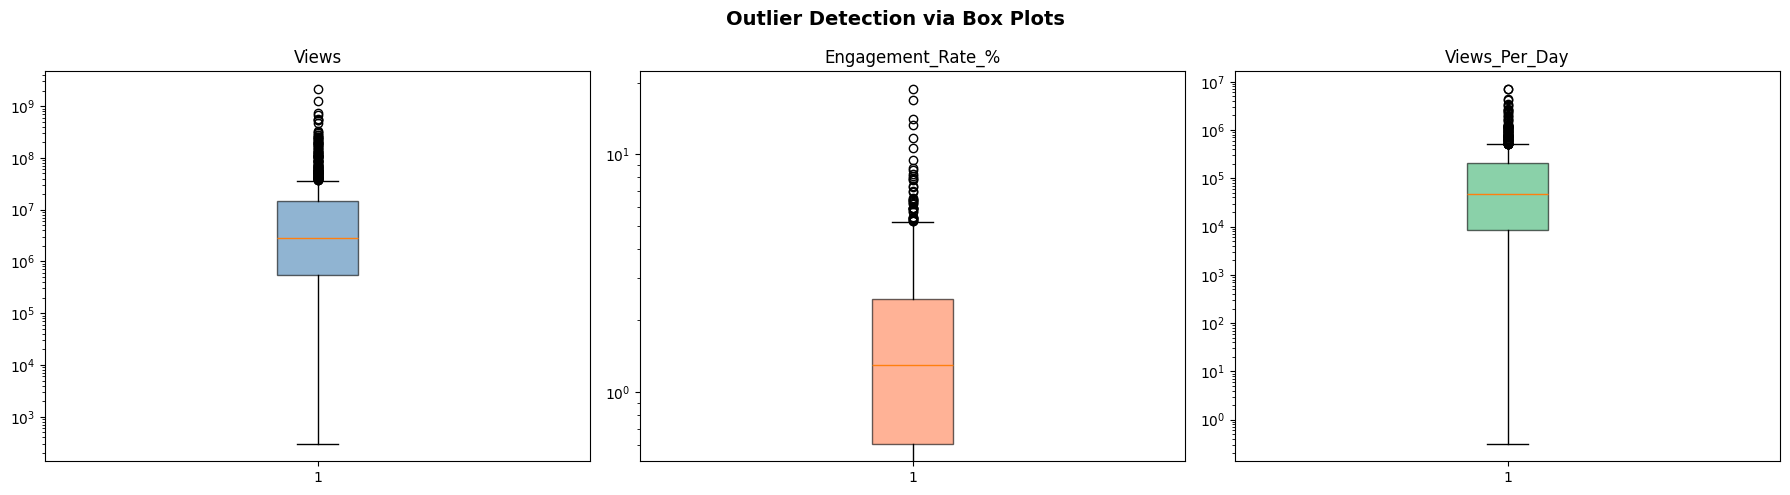

In [10]:
# Outlier detection — box plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
for ax, col, color in zip(
    axes,
    ["Views", "Engagement_Rate_%", "Views_Per_Day"],
    ["steelblue", "coral", "mediumseagreen"],
):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(col)
    ax.set_yscale("log")
plt.tight_layout()
plt.savefig("04_boxplots_outliers.png", dpi=150)
plt.show()

## NLP & TEXT MINING 

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from textblob import TextBlob
from wordcloud import WordCloud

In [12]:
#  Feature extraction — Title_Length & Emoji_Count
def count_emojis(text):
    return sum(1 for ch in str(text) if ch in emoji.EMOJI_DATA)
 
df["Title_Length"] = df["Title"].str.len()
df["Emoji_Count"] = df["Title"].apply(count_emojis)
 
print("\n── Title_Length & Emoji_Count sample:")
print(df[["Title", "Title_Length", "Emoji_Count"]].head(10))
print(f"\nMean Title Length : {df['Title_Length'].mean():.1f} chars")
print(f"Mean Emoji Count  : {df['Emoji_Count'].mean():.2f}")


── Title_Length & Emoji_Count sample:
                                               Title  Title_Length  \
0               How YouTube Wants You to Make Shorts            36   
1                Most Viewed YouTube Shorts! *VIRAL*            35   
2  How to Make Money with YouTube Shorts (Full Gu...            50   
3  How to Make a YouTube Short - Complete Beginne...            53   
4          *NEW* World’s MOST Viewed YouTube Shorts!            41   
5  fastest way to hit $10k/mo with yt shorts (cop...            51   
6                     Roasting Cringe YouTube Shorts            30   
7  Speedrunning 300 YT Shorts (Any% Brainrot WORL...            62   
8               #Youtube #funny #fyp #foryou #shorts            36   
9    200 Genius Secrets I Learned on YouTube Shorts!            47   

   Emoji_Count  
0            0  
1            0  
2            0  
3            0  
4            0  
5            0  
6            0  
7            0  
8            0  
9            0  

Me

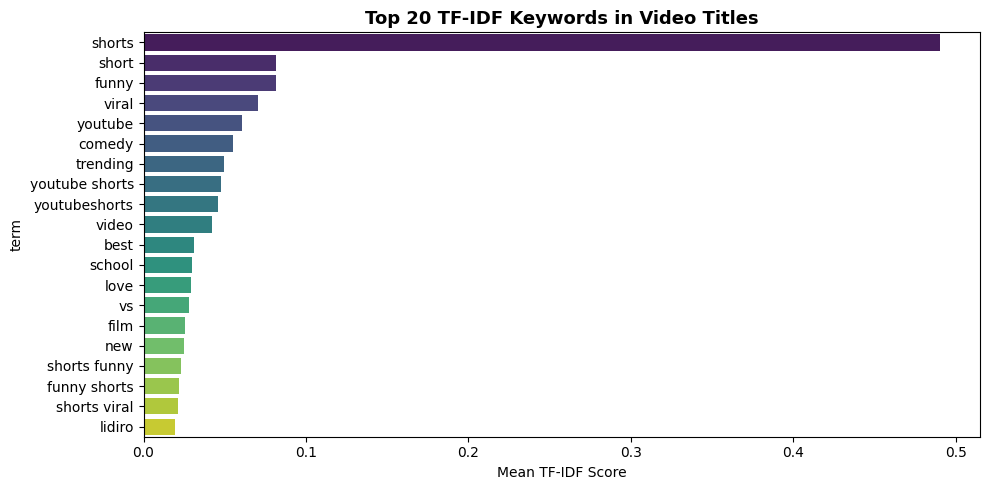

In [13]:
#  TF-IDF top keywords
tfidf = TfidfVectorizer(max_features=20, stop_words="english", ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df["Title"].fillna(""))
tfidf_scores = tfidf_matrix.mean(axis=0).A1
tfidf_df = pd.DataFrame({"term": tfidf.get_feature_names_out(), "score": tfidf_scores})
tfidf_df = tfidf_df.sort_values("score", ascending=False)
 
plt.figure(figsize=(10, 5))
sns.barplot(data=tfidf_df, x="score", y="term", palette="viridis")
plt.title("Top 20 TF-IDF Keywords in Video Titles", fontsize=13, fontweight="bold")
plt.xlabel("Mean TF-IDF Score")
plt.tight_layout()
plt.savefig("05_tfidf_keywords.png", dpi=150)
plt.show()

## Sentiment Analyze (TextBlob + VADER)

In [14]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.8 MB/s eta 0:00:00


In [15]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
# TextBlob + VADER
analyzer = SentimentIntensityAnalyzer()
 
df["Sentiment_TextBlob"] = df["Title"].apply(
    lambda t: TextBlob(str(t)).sentiment.polarity
)
df["Sentiment_VADER"] = df["Title"].apply(
    lambda t: analyzer.polarity_scores(str(t))["compound"]
)
 
# now i have used Correlation with Engagement_Rate
tb_corr   = df["Sentiment_TextBlob"].corr(df["Engagement_Rate_%"])
vad_corr  = df["Sentiment_VADER"].corr(df["Engagement_Rate_%"])
print(f"\n── TextBlob sentiment  Engagement_Rate_%  : {tb_corr:.4f}")
print(f"── VADER   sentiment  Engagement_Rate_%  : {vad_corr:.4f}")


── TextBlob sentiment  Engagement_Rate_%  : -0.1331
── VADER   sentiment  Engagement_Rate_%  : -0.1424


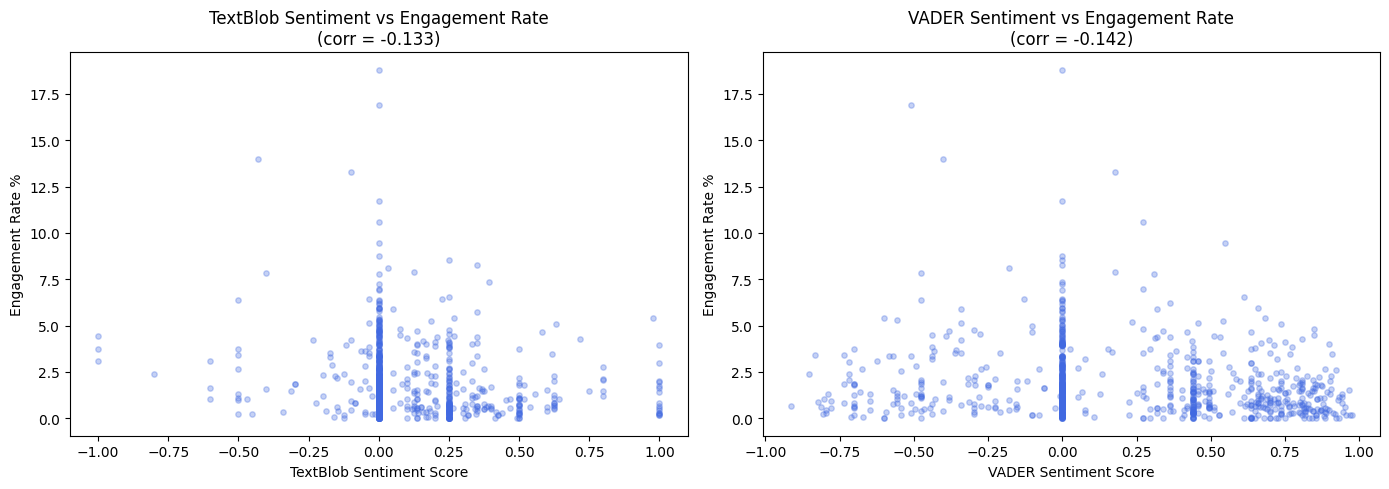

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in zip(
    axes,
    ["Sentiment_TextBlob", "Sentiment_VADER"],
    ["TextBlob", "VADER"],
):
    ax.scatter(df[col], df["Engagement_Rate_%"], alpha=0.3, s=15, color="royalblue")
    ax.set_xlabel(f"{label} Sentiment Score")
    ax.set_ylabel("Engagement Rate %")
    ax.set_title(f"{label} Sentiment vs Engagement Rate\n(corr = {df[col].corr(df['Engagement_Rate_%']):.3f})")
plt.tight_layout()
plt.savefig("06_sentiment_vs_engagement.png", dpi=150)
plt.show()

## K-Means Clustering

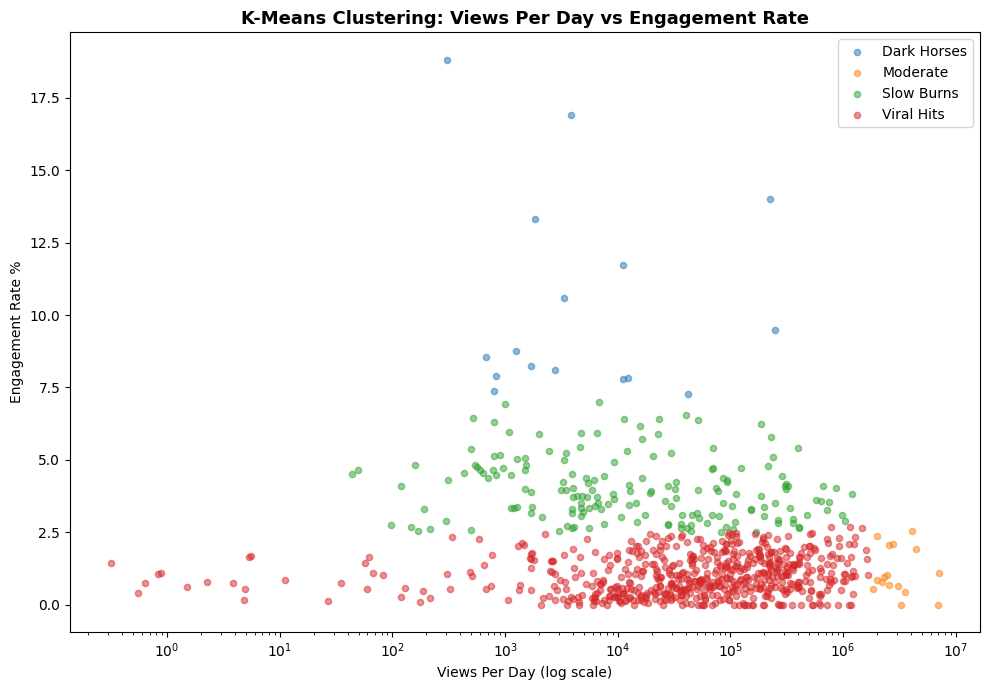

In [17]:

cluster_features = df[["Views_Per_Day", "Engagement_Rate_%"]].copy()
scaler_c = StandardScaler()
cluster_scaled = scaler_c.fit_transform(cluster_features)
 
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(cluster_scaled)
 
cluster_labels = {0: "Moderate", 1: "Viral Hits", 2: "Slow Burns", 3: "Dark Horses"}
palette = {0: "steelblue", 1: "crimson", 2: "gray", 3: "darkorange"}
 
centres = (
    pd.DataFrame(
        scaler_c.inverse_transform(kmeans.cluster_centers_),
        columns=["Views_Per_Day", "Engagement_Rate_%"],
    )
    .sort_values("Views_Per_Day", ascending=False)
    .reset_index()
)
rank_map = {centres.loc[i, "index"]: list(cluster_labels.values())[i] for i in range(4)}
df["Cluster_Label"] = df["Cluster"].map(rank_map)
 
plt.figure(figsize=(10, 7))
for label, grp in df.groupby("Cluster_Label"):
    plt.scatter(grp["Views_Per_Day"], grp["Engagement_Rate_%"],
                label=label, alpha=0.5, s=20)
plt.xscale("log")
plt.xlabel("Views Per Day (log scale)")
plt.ylabel("Engagement Rate %")
plt.title("K-Means Clustering: Views Per Day vs Engagement Rate", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("08_kmeans_clusters.png", dpi=150)
plt.show()

In [18]:
print("\n── Cluster summary:")
print(
    df.groupby("Cluster_Label")[["Views_Per_Day", "Engagement_Rate_%"]]
    .mean()
    .round(2)
)


── Cluster summary:
               Views_Per_Day  Engagement_Rate_%
Cluster_Label                                  
Dark Horses         35243.09              10.42
Moderate          3321443.57               1.13
Slow Burns          99351.62               3.99
Viral Hits         179755.35               1.02


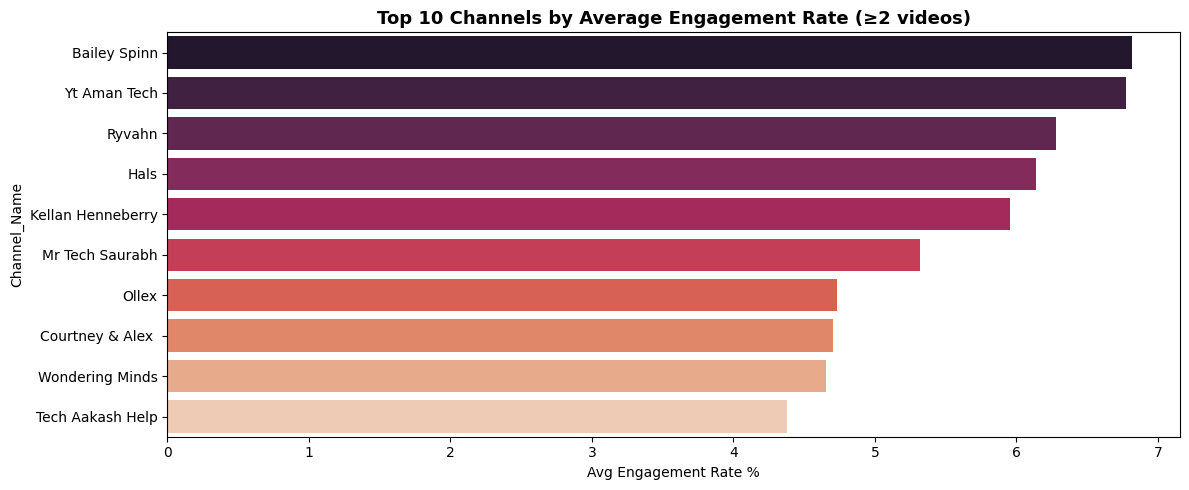

In [19]:
#  Channel Benchmarking — top 10 channels by avg engagement
channel_stats = (
    df.groupby("Channel_Name")
    .agg(
        Avg_Engagement=("Engagement_Rate_%", "mean"),
        Avg_Views_Per_Day=("Views_Per_Day", "mean"),
        Video_Count=("Video_ID", "count"),
    )
    .query("Video_Count >= 2")          # at least 2 videos for reliability
    .sort_values("Avg_Engagement", ascending=False)
    .head(10)
    .reset_index()
)
 
plt.figure(figsize=(12, 5))
sns.barplot(data=channel_stats, x="Avg_Engagement", y="Channel_Name", palette="rocket")
plt.title("Top 10 Channels by Average Engagement Rate (≥2 videos)", fontsize=13, fontweight="bold")
plt.xlabel("Avg Engagement Rate %")
plt.tight_layout()
plt.savefig("09_channel_benchmarking.png", dpi=150)
plt.show()

In [20]:
# Feature engineering
df["Has_Emoji"] = (df["Emoji_Count"] > 0).astype(int)
df["Has_Hashtag"] = df["Title"].str.contains(r"#\w+", regex=True).astype(int)
 
feature_cols = [
    "Title_Length", "Emoji_Count", "Description_Length",
    "Age_In_Days", "Has_Emoji", "Has_Hashtag",
    "Likes", "Comments",              # strong signals, kept deliberately
]
target = "Views_Per_Day"

## PREDICTIVE MODELING (REGRESSION)

In [21]:
model_df = df[feature_cols + [target]].dropna()
X = model_df[feature_cols]
y = np.log1p(model_df[target])        # log-transform target (right-skewed)
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [22]:
# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
rf_preds = rf.predict(X_test_s)
 
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2  = r2_score(y_test, rf_preds)
print(f"\n── Random Forest  →  MAE: {rf_mae:.4f}  |  R²: {rf_r2:.4f}")
 
# XGBoost
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05,
                   max_depth=5, random_state=42,
                   verbosity=0, n_jobs=-1)
xgb.fit(X_train_s, y_train)
xgb_preds = xgb.predict(X_test_s)
 
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_r2  = r2_score(y_test, xgb_preds)
print(f"── XGBoost        →  MAE: {xgb_mae:.4f}  |  R²: {xgb_r2:.4f}")


── Random Forest  →  MAE: 0.6931  |  R²: 0.8720
── XGBoost        →  MAE: 0.7160  |  R²: 0.8627


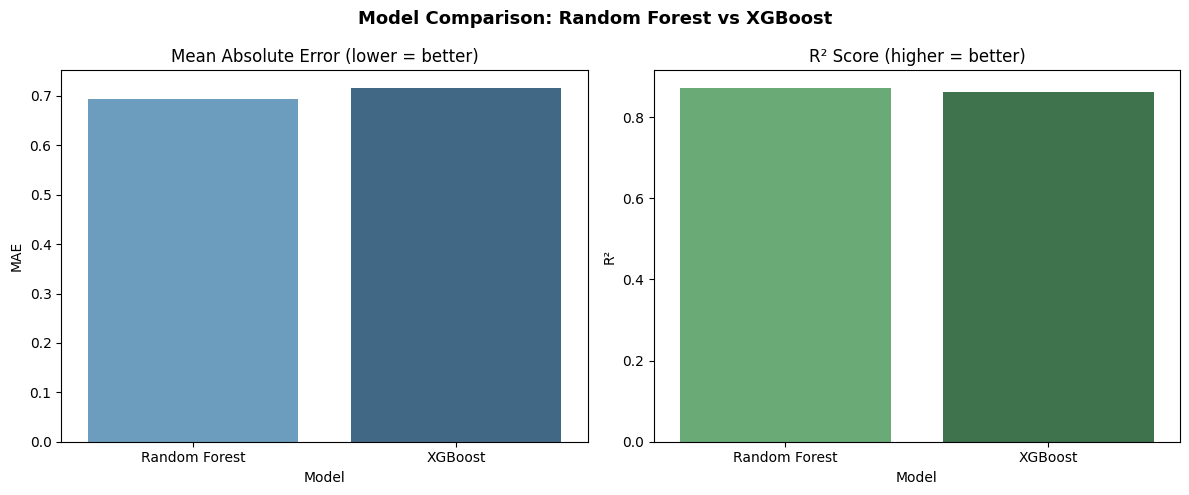

In [23]:
# Model comparison bar chart
comparison_df = pd.DataFrame({
    "Model":  ["Random Forest", "XGBoost"],
    "MAE":    [rf_mae, xgb_mae],
    "R²":     [rf_r2, xgb_r2],
})
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Model Comparison: Random Forest vs XGBoost", fontsize=13, fontweight="bold")
sns.barplot(data=comparison_df, x="Model", y="MAE", ax=axes[0], palette="Blues_d")
axes[0].set_title("Mean Absolute Error (lower = better)")
sns.barplot(data=comparison_df, x="Model", y="R²", ax=axes[1], palette="Greens_d")
axes[1].set_title("R² Score (higher = better)")
plt.tight_layout()
plt.savefig("10_model_comparison.png", dpi=150)
plt.show()

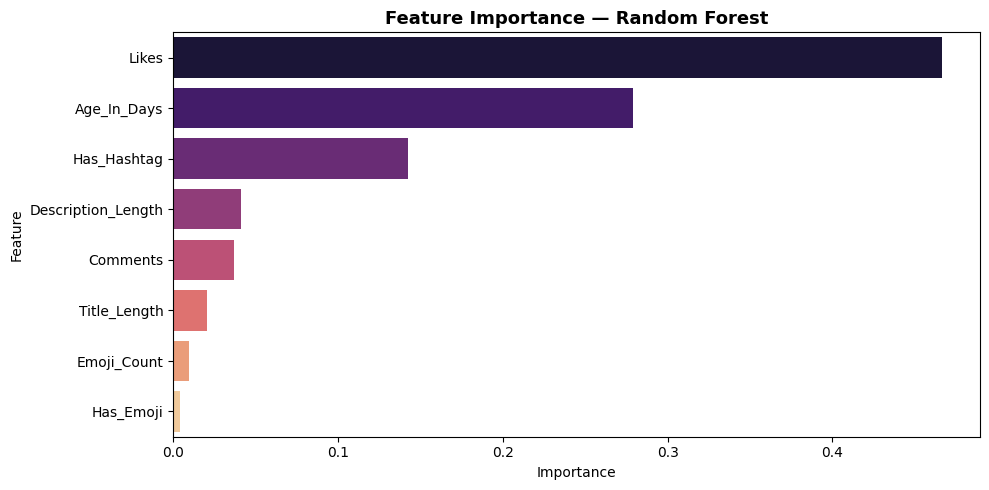

In [24]:
# Feature importance from the better model (pick higher R²)
best_model = xgb if xgb_r2 >= rf_r2 else rf
importance_df = (
    pd.DataFrame({"Feature": feature_cols, "Importance": best_model.feature_importances_})
    .sort_values("Importance", ascending=False)
)
 
plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="magma")
plt.title(f"Feature Importance — {'XGBoost' if best_model is xgb else 'Random Forest'}",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("11_feature_importance.png", dpi=150)
plt.show()

## EVALUATION & INSIGHTS

In [25]:
# Split videos into high/low engagement using median
median_eng = df["Engagement_Rate_%"].median()
high_eng = df[df["Engagement_Rate_%"] >= median_eng]
low_eng  = df[df["Engagement_Rate_%"] <  median_eng]
 
print(f"\n── Engagement threshold (median): {median_eng:.2f}%")
print(f"\n── HIGH engagement group stats:")
print(high_eng[["Title_Length", "Emoji_Count", "Description_Length",
                "Age_In_Days", "Views_Per_Day"]].describe().round(2))
print(f"\n── LOW engagement group stats:")
print(low_eng[["Title_Length", "Emoji_Count", "Description_Length",
               "Age_In_Days", "Views_Per_Day"]].describe().round(2))


── Engagement threshold (median): 1.30%

── HIGH engagement group stats:
       Title_Length  Emoji_Count  Description_Length  Age_In_Days  \
count        400.00       400.00              400.00       400.00   
mean          61.34         0.88              504.91       244.88   
std           20.69         0.99              946.08       499.50   
min           20.00         0.00                0.00         1.00   
25%           45.00         0.00                0.00         6.00   
50%           59.00         1.00               68.00        38.00   
75%           79.00         2.00              607.25       239.25   
max          100.00         4.00             4864.00      4241.00   

       Views_Per_Day  
count         400.00  
mean       198118.49  
std        442698.45  
min             0.32  
25%          5293.25  
50%         45409.98  
75%        200778.25  
max       4409967.00  

── LOW engagement group stats:
       Title_Length  Emoji_Count  Description_Length  Age_In_Days

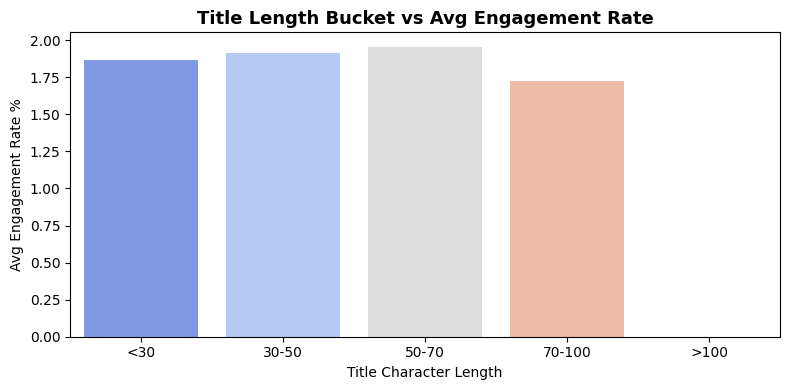

In [26]:
# Title-length buckets vs engagement
bins = [0, 30, 50, 70, 100, 200]
labels_b = ["<30", "30-50", "50-70", "70-100", ">100"]
df["Title_Len_Bucket"] = pd.cut(df["Title_Length"], bins=bins, labels=labels_b)
 
bucket_eng = (
    df.groupby("Title_Len_Bucket", observed=True)["Engagement_Rate_%"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8, 4))
sns.barplot(data=bucket_eng, x="Title_Len_Bucket", y="Engagement_Rate_%", palette="coolwarm")
plt.title("Title Length Bucket vs Avg Engagement Rate", fontsize=13, fontweight="bold")
plt.xlabel("Title Character Length")
plt.ylabel("Avg Engagement Rate %")
plt.tight_layout()
plt.savefig("12_title_length_vs_engagement.png", dpi=150)
plt.show()

## Final summary
* Best title length bucket  : 50-70 characters
* 2+ emojis boost engagement: -0.28% vs <2 emojis
* Optimal description length: 505 chars (high-eng avg)
* Newer videos dominate velocity (Age_In_Days negatively correlated)
* Random Forest  → MAE: 0.6931, R²: 0.8720
* XGBoost        → MAE: 0.7160, R²: 0.8627
* Best model: Random Forest